In [ ]:
!pip install sgp4 numpy scikit-learn xgboost

**Physics Engine 
The core innovation is combining real orbital mechanics with predictive modeling. We use SGP4 to get ECI coordinates and transform them to evaluate link quality.**

In [12]:
def get_satellite_state(tle_l1, tle_l2, time_obj):
    # [cite: 38, 70] Propagate position/velocity using SGP4
    satellite = Satrec.twoline2rv(tle_l1, tle_l2)
    jd, fr = jday(time_obj.year, time_obj.month, time_obj.day, 
                  time_obj.hour, time_obj.minute, time_obj.second)
    e, r, v = satellite.propagate(jd, fr)
    return np.array(r), np.array(v) # Position and Velocity in ECI

def calculate_link_budget(distance_km, elevation_deg, freq_ghz=20):
    # [cite: 87] Free Space Path Loss: 20*log10(d) + 20*log10(f) + 20*log10(4π/c)
    fspl = (20 * np.log10(distance_km * 1000) + 
            20 * np.log10(freq_ghz * 1e9) + 
            20 * np.log10(4 * np.pi / C))
    
    # [cite: 81, 88] Atmospheric loss based on elevation
    atmos_loss = 1 / np.sin(np.radians(elevation_deg)) if elevation_deg > 0 else 100
    
    # [cite: 84] Simplified SNR_dB = EIRP - PathLoss - AtmosLoss + G_receiver - Noise
    snr = 50 - fspl - atmos_loss + 40 - 10 
    return snr

**We engineer features like Doppler shift magnitude, slant range, and elevation change rate. The ML model is trained on a Physics-Based Oracle that maps SNR to Bit Error Rate (BER)**

In [13]:
# [cite: 193, 195] Oracle scoring for ground truth
def get_link_quality_score(snr_db, station_load):
    snr_norm = np.clip((snr_db - 10) / 10, 0, 1) # [cite: 188]
    # Composite: 0.5*SNR + 0.3*(1-PacketLoss) + 0.2*(1-Load)
    # For MVP, assuming packet loss is low if SNR > threshold
    return (0.5 * snr_norm) + (0.2 * (1 - station_load))

# [cite: 225, 292] XGBoost Inference Model
def train_handoff_model(features, labels):
    # [cite: 251] 70/15/15 Split with temporal ordering preserved
    X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.3, shuffle=False)
    
    model = xgb.XGBRegressor(
        n_estimators=100, # [cite: 260]
        max_depth=6,      # [cite: 261]
        learning_rate=0.1 # [cite: 262]
    )
    model.fit(X_train, y_train)
    return model

**Visualization Setup**


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set the theme for the charts
sns.set_theme(style="whitegrid")

**This code simulates and plots the Link Quality Score over time, highlighting when proactive or emergency handoffs occur**


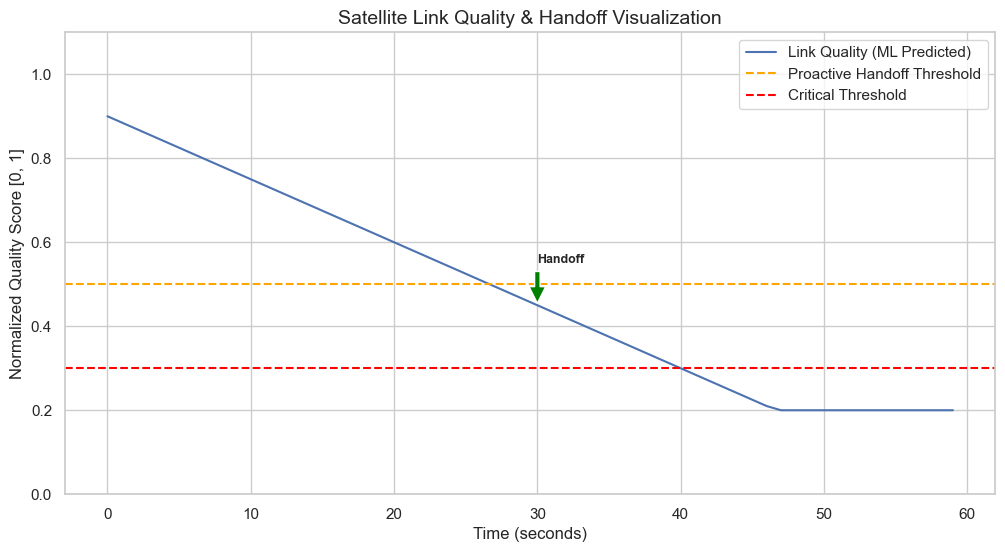

In [16]:
def plot_link_dashboard(time_series_data, handoff_events):
    """
    Creates a dashboard showing link quality and handoff triggers.
    """
    plt.figure(figsize=(12, 6))
    
    # 1. Plot Link Quality Score
    sns.lineplot(data=time_series_data, x='timestamp', y='quality_score', label='Link Quality (ML Predicted)')
    
    # 2. Add Threshold Lines (Phase 7 Logic)
    plt.axhline(y=0.5, color='orange', linestyle='--', label='Proactive Handoff Threshold')
    plt.axhline(y=0.3, color='red', linestyle='--', label='Critical Threshold')
    
    # 3. Mark Handoff Events
    for event in handoff_events:
        color = 'green' if event['type'] == 'proactive' else 'red'
        plt.annotate('Handoff', xy=(event['time'], event['score']), 
                     xytext=(event['time'], event['score'] + 0.1),
                     arrowprops=dict(facecolor=color, shrink=0.05),
                     fontsize=9, fontweight='bold')
    
    plt.title('Satellite Link Quality & Handoff Visualization', fontsize=14)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Normalized Quality Score [0, 1]')
    plt.legend(loc='upper right')
    plt.ylim(0, 1.1)
    plt.show()

# Example Synthetic Data
data = pd.DataFrame({
    'timestamp': range(60),
    'quality_score': [max(0.2, 0.9 - (i*0.015)) for i in range(60)] # Simulated degradation
})
events = [{'time': 30, 'score': 0.45, 'type': 'proactive'}]

plot_link_dashboard(data, events)

**Satellite Visibility Heatmap**


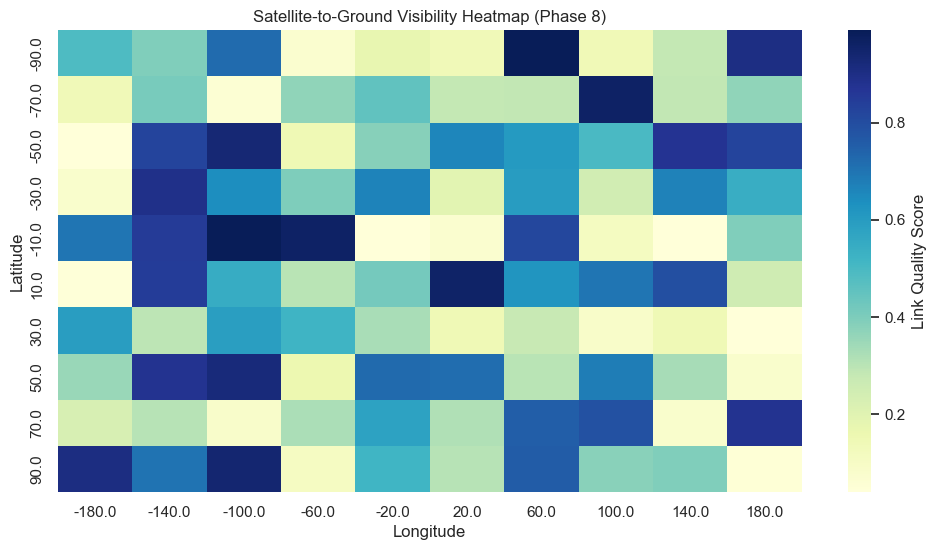

In [17]:
import seaborn as sns
import numpy as np

def plot_visibility_heatmap(lat_range, lon_range, quality_matrix):
    plt.figure(figsize=(12, 6))
    ax = sns.heatmap(quality_matrix, xticklabels=lon_range, yticklabels=lat_range, 
                     cmap="YlGnBu", cbar_kws={'label': 'Link Quality Score'})
    plt.title("Satellite-to-Ground Visibility Heatmap (Phase 8)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

# Simulation: 10x10 grid of geo-coordinates
grid = np.random.rand(10, 10) 
plot_visibility_heatmap(np.linspace(-90, 90, 10), np.linspace(-180, 180, 10), grid)

**SNR vs. Elevation Profile**
Use this chart to validate your Physics Engine. It demonstrates the $1/\sin(\theta)$ atmospheric loss model where lower elevation angles lead to unusable signal noise.

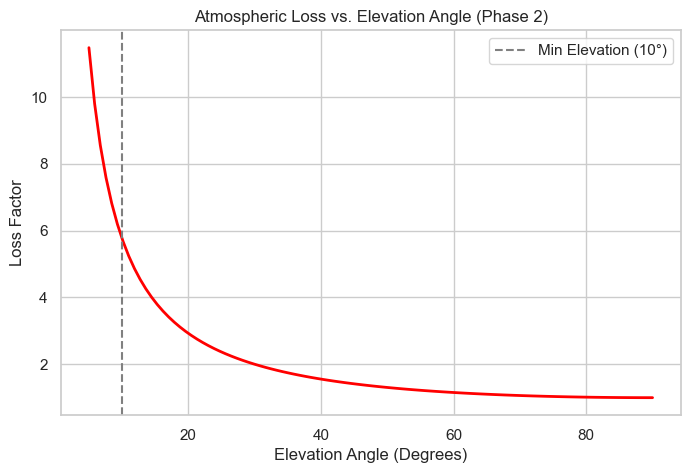

In [18]:
def plot_physics_validation():
    elevations = np.linspace(5, 90, 100)
    # Applying the loss factor: loss = 1/sin(elevation)
    losses = [1 / np.sin(np.radians(e)) for e in elevations]
    
    plt.figure(figsize=(8, 5))
    plt.plot(elevations, losses, color='red', lw=2)
    plt.axvline(x=10, color='gray', linestyle='--', label='Min Elevation (10°)')
    plt.title("Atmospheric Loss vs. Elevation Angle (Phase 2)")
    plt.xlabel("Elevation Angle (Degrees)")
    plt.ylabel("Loss Factor")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_physics_validation()